## Figure 7. Storm direction by seasons

In [13]:
#Packages:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import scrapbook as sb
import sys
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
warnings.filterwarnings("ignore")


In [14]:
# import plottig functions
from pathlib import Path
import sys
# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.diagnostic_plots import circular_percentile, circular_mean, circular_trend, circular_trend_permutation_test

In [15]:
# ── 1) LOAD GRID ─────────────────────────────────────────────────────────────
shp_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/CONUS_5d_grid.shp"
grid = gpd.read_file(shp_path)

# Make sure we’re in geographic coordinates for Cartopy plotting
grid = grid.to_crs(epsg=4326)

In [16]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
storm_stats = os.listdir(f)
storm_stats = [file for file in storm_stats if file.endswith('.csv')]

centroids = grid.geometry.centroid
xs = centroids.x.values
ys = centroids.y.values

domains = pd.DataFrame(index=grid['D_name'], columns=["x", "y"])
domains["x"] = xs
domains["y"] = ys

In [17]:
## function for domain stats
def _month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Fall'


def _compute_variable_stats(df_subset, key, perform_direction_trend=False):
    row = {}

    if key == 'dir':
        directions = df_subset['storm_direction'].dropna()
        if directions.empty:
            return row

        row['mean'] = circular_mean(directions)
        row['median'] = circular_percentile(directions, 50)
        row['p75'] = circular_percentile(directions, 75)
        row['p25'] = circular_percentile(directions, 25)
        row['p5'] = circular_percentile(directions, 5)
        row['p95'] = circular_percentile(directions, 95)
        row['max'] = directions.max()
        row['min'] = directions.min()

        if perform_direction_trend:
            df_year = df_subset.resample('YE').apply(lambda x: x.loc[x['mean_intensity'].idxmax()])
            x = np.arange(len(df_year))
            if len(df_year) > 1 and df_year['storm_direction'].nunique() > 1:
                results = circular_trend_permutation_test(x, df_year['storm_direction'], n_permutations=10000)
                row['trend'] = results['rate_direction_deg']
                row['p_value'] = results['p_value']
            else:
                row['trend'] = np.nan
                row['p_value'] = np.nan

    elif key == 'speed':
        values = df_subset['storm_velocity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'intensity':
        values = df_subset['mean_intensity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'area':
        values = df_subset['area'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'angular_var':
        values = df_subset['angular_variance_weighted'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)

    return row


def compute_stats_by_season(df, key, perform_direction_trend=False):
    season_groups = {'ALL': df}
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        season_groups[season] = df[df['season'] == season]

    seasonal_stats = {}
    for season_name, season_df in season_groups.items():
        seasonal_stats[season_name] = _compute_variable_stats(
            season_df,
            key,
            perform_direction_trend=(perform_direction_trend and season_name == 'ALL'),
        )
    return seasonal_stats


def domain_stats_func(top_storms, perform_direction_trend=False, filter_events=False, linear_trajectory_threshold=0.51):
    variable_keys = ['dir', 'speed', 'intensity', 'area', 'angular_var']
    season_keys = ['ALL', 'Winter', 'Spring', 'Summer', 'Fall']
    stats = {key: {season: pd.DataFrame() for season in season_keys} for key in variable_keys}

    for cat in grid['D_name']:
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(f + '/' + cat_file)
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        df = df[df['id'] > (400 - top_storms)].copy()
        # filter by linear trajectory threshold
        if filter_events:
            df = df[df['angular_variance_weighted'] < linear_trajectory_threshold]
        # get the date from the domain name
        df.index = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
        df.drop(columns=['storm_event'], inplace=True)
        df = df.sort_values(by=df.index.name)
        df['season'] = df.index.month.map(_month_to_season)

        domain_x = domains.loc[cat]['x']
        domain_y = domains.loc[cat]['y']

        for key in variable_keys:
            seasonal_stats = compute_stats_by_season(
                df,
                key,
                perform_direction_trend=perform_direction_trend,
            )

            for season_name, values in seasonal_stats.items():
                for stat_name, stat_value in values.items():
                    stats[key][season_name].loc[cat, stat_name] = stat_value
                stats[key][season_name].loc[cat, 'centroid_x'] = domain_x
                stats[key][season_name].loc[cat, 'centroid_y'] = domain_y

    for key in variable_keys:
        for season_name in season_keys:
            stats[key][season_name].reset_index(inplace=True)
            stats[key][season_name].rename(columns={'index': 'Domain'}, inplace=True)

    return stats

In [18]:
top_storms = 400
stats = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)

## Direction fans plot function

In [19]:
# Define the function, where it is plotted using the CONUS as a basemap
def plot_directional_arrow_fan_season(x_center, y_center, direction_percentiles, magnitude, ax, season, main_direction=None):
    """
    Plot a directional arrow with two percentile fans.

    Parameters:
    - x_center, y_center: Center coordinates for the arrow
    - direction_percentiles: Iterable [p5, p25, p50, p75, p95] in degrees
    - magnitude: Length of the arrow in degrees
    - ax: Matplotlib axis with PlateCarree projection
    - main_direction: Optional mean direction in degrees (defaults to p50)
    """
    # Define Seasons and Colors for the fans
    seasons = ['Winter', 'Spring', 'Summer', 'Fall']
    # Season-representative colors
    colors = [ '#2181BD','#90EE90', '#FFD700', '#FF8C00']  # Spring-green, Summer-yellow, Fall-orange, Winter-blue
    # Map season to color
    season_color_map = dict(zip(seasons, colors))

    direction_percentiles = np.asarray(direction_percentiles, dtype=float)
    if direction_percentiles.shape[0] != 5:
        raise ValueError("direction_percentiles must have five values [5, 25, 50, 75, 95].")

    # Unwrap around the median (50th percentile) so spreads straddle 0/360 correctly
    median_dir = direction_percentiles[2]
    centered = (direction_percentiles - median_dir + 180) % 360 - 180 + median_dir
    p5, p25, p50, p75, p95 = centered

    main_dir = main_direction if main_direction is not None else p50

    # Convert angles from degrees to radians
    #main_angle_rad = np.radians(main_dir)
    median_angle_rad = np.radians(p50)

    # Calculate arrow endpoints
    #arrow_end_x = x_center + magnitude * np.cos(main_angle_rad)
    #arrow_end_y = y_center + magnitude * np.sin(main_angle_rad)

    median_end_x = x_center + magnitude * np.cos(median_angle_rad)
    median_end_y = y_center + magnitude * np.sin(median_angle_rad)

   
    def _add_fan(angle_low, angle_high, color, alpha):
        start = min(angle_low, angle_high)
        end = max(angle_low, angle_high)
        arc_angles = np.linspace(start, end, 80)
        arc_x = x_center + magnitude * np.cos(np.radians(arc_angles))
        arc_y = y_center + magnitude * np.sin(np.radians(arc_angles))

        fan_vertices = [(x_center, y_center)]
        fan_vertices.append((x_center + magnitude * np.cos(np.radians(angle_low)),
                             y_center + magnitude * np.sin(np.radians(angle_low))))
        fan_vertices.extend(zip(arc_x, arc_y))
        fan_vertices.append((x_center + magnitude * np.cos(np.radians(angle_high)),
                             y_center + magnitude * np.sin(np.radians(angle_high))))
        fan_vertices.append((x_center, y_center))

        fan = Polygon(fan_vertices, alpha=alpha, color=color, transform=ccrs.PlateCarree())
        #ax.add_patch(fan)
        ax.plot([x_center, fan_vertices[1][0]], [y_center, fan_vertices[1][1]],
                color=color, linestyle='--', linewidth=1.2, alpha=0.9, transform=ccrs.PlateCarree())
        ax.plot([x_center, fan_vertices[-2][0]], [y_center, fan_vertices[-2][1]],
                color=color, linestyle='--', linewidth=1.2, alpha=0.9, transform=ccrs.PlateCarree())
        ax.plot(arc_x, arc_y, color=color, linestyle='-', linewidth=1.2, alpha=0.9, transform=ccrs.PlateCarree())

    # Outer (5–95) and inner (25–75) fans
    #_add_fan(p5, p95, color='skyblue', alpha=0.5)
    _add_fan( p25, p75, color = season_color_map[season], alpha=0.5)

    # Plot the main and median arrows
    ax.annotate('', xy=(median_end_x, median_end_y), xytext=(x_center, y_center),
                arrowprops=dict(arrowstyle='->', color= season_color_map[season], lw=2.5),
                transform=ccrs.PlateCarree())

    # Add center point
    ax.plot(x_center, y_center, 'ko', markersize=4, transform=ccrs.PlateCarree())


def plot_directional_arrow_fan_grid(
    direction_percentiles_by_season,
    main_direction_by_season=None,
    magnitude=5,
    target_ax=None,
    figsize=(8, 8),
    season_order=('Winter', 'Spring', 'Summer', 'Fall'),
    panel_pad=0.0,
):
    from matplotlib.colors import to_rgba

    season_color_map = {'Winter': '#2181BD', 'Spring': '#90EE90', 'Summer': '#FFD700', 'Fall': '#FF8C00'}

    if main_direction_by_season is None:
        main_direction_by_season = {}

    if target_ax is None:
        fig, axes = plt.subplots(2, 2, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
        axes = axes.ravel()
    else:
        fig = target_ax.figure
        bbox = target_ax.get_position()
        x0, y0, w, h = bbox.x0, bbox.y0, bbox.width, bbox.height
        target_ax.axis('on')

        # Fix: divide space exactly in half with no gaps
        cell_w = w / 2.0
        cell_h = h / 2.0

        panel_positions = [
            [x0,          y0 + cell_h, cell_w, cell_h],  # top-left
            [x0 + cell_w, y0 + cell_h, cell_w, cell_h],  # top-right
            [x0,          y0,          cell_w, cell_h],  # bottom-left
            [x0 + cell_w, y0,          cell_w, cell_h],  # bottom-right
        ]

        axes = [
            fig.add_axes(pos, projection=ccrs.PlateCarree())
            for pos in panel_positions
        ]

    for i, season in enumerate(season_order):
        ax = axes[i]
        lim = magnitude * 1.3
        ax.set_extent([-lim, lim, -lim, lim], crs=ccrs.PlateCarree())
        ax.set_facecolor(to_rgba(season_color_map[season], 0.08))

        if season in direction_percentiles_by_season:
            plot_directional_arrow_fan_season(
                x_center=0,
                y_center=0,
                direction_percentiles=direction_percentiles_by_season[season],
                magnitude=magnitude,
                ax=ax,
                season=season,
                main_direction=main_direction_by_season.get(season, None),
            )

        # Fix: remove titles entirely — they overflow small insets
        ax.set_xticks([])
        ax.set_yticks([])
        ax.coastlines(resolution='110m', linewidth=0.2, alpha=0.2)

        # Fix: remove set_aspect('equal') — it shrinks axes away from cell boundaries
        # Cartopy's PlateCarree will naturally be square given equal extent ranges

        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
            spine.set_edgecolor(season_color_map[season])

    if target_ax is None:
        plt.tight_layout()

    return fig, axes


def plot_directional_arrow_fan_season_grid(*args, **kwargs):
    """Backward-compatible alias."""
    return plot_directional_arrow_fan_grid(*args, **kwargs)


def plot_directional_fan_grid_legend(ax, season_order=('Winter', 'Spring', 'Summer', 'Fall')):
    """
    Draw a compact legend describing seasonal colors and fan/arrow representation.
    """
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    from matplotlib.colors import to_rgba

    season_color_map = {'Winter': '#2181BD', 'Spring': '#90EE90', 'Summer': '#FFD700', 'Fall': '#FF8C00'}

    season_handles = [
        Patch(facecolor=to_rgba(season_color_map[s], 0.25), edgecolor=season_color_map[s], label=s)
        for s in season_order
    ]

    style_handles = [
        Line2D([0], [0], color='black', lw=2.2, marker='>', markevery=[1], label='Median direction arrow (p50)'),
        Line2D([0], [0], color='black', lw=1.2, ls='--', label='25th/75th directional bounds'),
        Line2D([0], [0], color='black', lw=1.2, ls='-', label='Fan arc (25th-75th)'),
        Line2D([0], [0], color='black', marker='o', linestyle='None', markersize=6, label='Domain centroid'),
    ]

    ax.axis('off')
    ax.legend(
        handles=season_handles + style_handles,
        loc='center',
        frameon=False,
        ncol=2,
        fontsize=9,
        title='Directional Fan Legend',
        title_fontsize=10,
    )





In [20]:
# ── 4) plot_directional_arrow_with_fan
top_storms = 400
domain_stats_all = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)



## Directional plot by season in grid

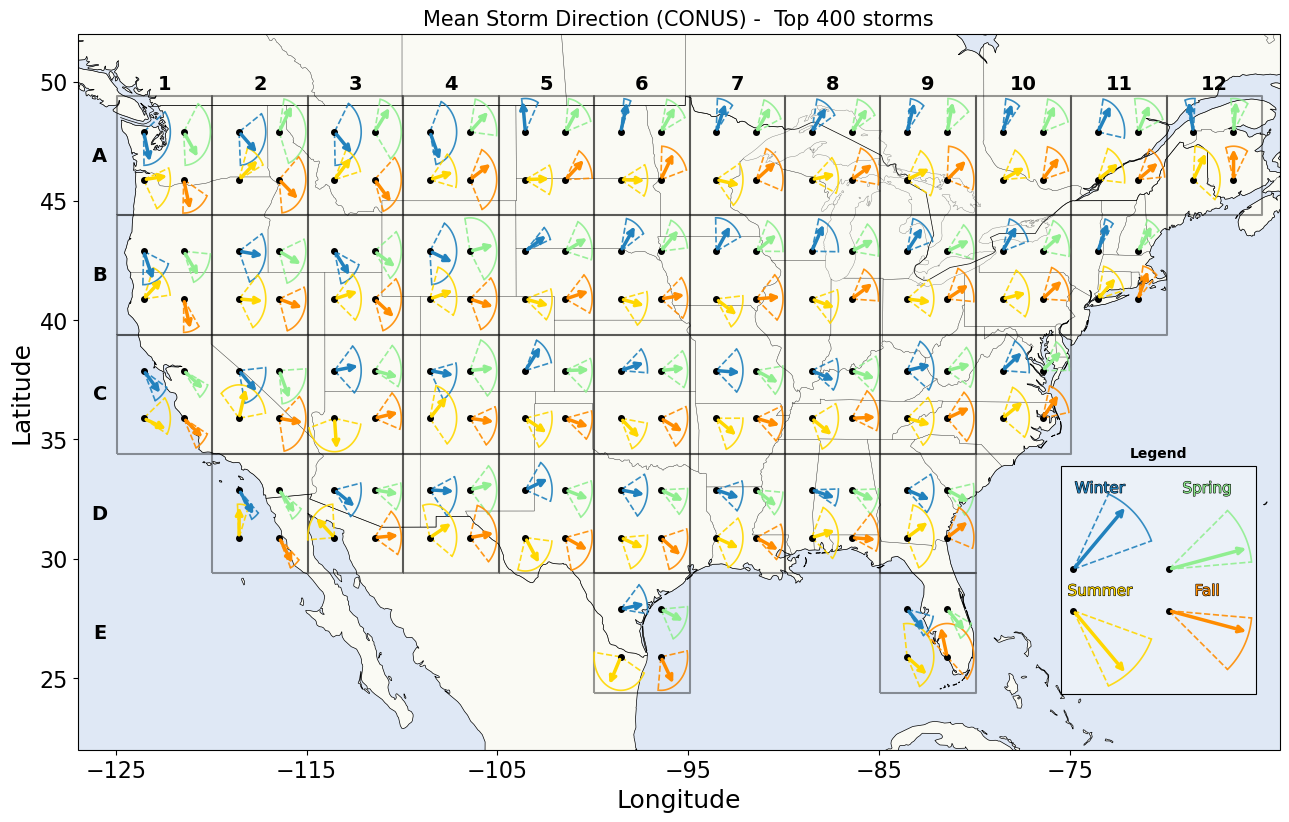

In [ ]:
# ── 2) Setup plot ─────────────────────────
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 9))
ax = plt.axes(projection=proj)

ax.set_extent([-127, -64, 22, 52], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.3)

# Optional: grid outline
grid.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), linewidth=1.5, alpha=0.4, color='black')


# ── 4) plot_directional_arrow_with_fan
top_storms = 400
domain_stats_all = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
for season in seasons:
    season_stats = domain_stats_all['dir'][season]
    for dom in season_stats.itertuples():

        # set an offset for each season to avoid overlaping of the fans
        x_offset = {'Winter': -1.1, 'Spring': 1, 'Summer': -1.1, 'Fall': 1.0}
        y_offset = {'Winter': 1, 'Spring': 1, 'Summer': -1, 'Fall': -1.0}


        plot_directional_arrow_fan_season(
            x_center=dom.centroid_x + x_offset[season],
            y_center=dom.centroid_y + y_offset[season],
            season=season,
            direction_percentiles=[dom.p5, dom.p25, dom.median, dom.p75, dom.p95],
            magnitude=1.4,  # adjust as needed
            ax=ax,
            main_direction=dom.mean,
        )

# add axis ticks
ax.set_xticks(np.arange(-125, -65, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(25, 55, 5), crs=ccrs.PlateCarree())
ax.tick_params(axis='both', which='major', labelsize=16)
## add axis labels
ax.set_xlabel('Longitude', fontsize=18)
ax.set_ylabel('Latitude', fontsize=18)
plt.title(f"Mean Storm Direction (CONUS) -  Top {top_storms} storms", fontsize=15)
plt.tight_layout()

# plot legend as an inset axis
inset_ax = plt.axes([0.82, 0.15, 0.15, 0.3], projection=ccrs.PlateCarree(), facecolor='white', alpha=0.01)
# Set limits for the inset axes
inset_ax.set_extent([-1.5, 3.2 ,-2.5, 3])
# Hide the axes
#inset_ax.axis('off')
# Plot an a directional arrow with fans for the legend

legend_percentiles = {
     'Summer': [-5,-20,-50,-65,-90],
     'Fall': [-5,-5,-15,-45,-90],
     'Winter': [5,20,50,65,90],
     'Spring': [5,5,15,45,90]
}  # Example percentiles for the legend


# Plot fans for remaining seasons in the legend
for s in ['Summer', 'Fall', 'Winter', 'Spring']:
    
    # offset for the center point to avoid overlapping of the arrows in the legend
    x_offset = {'Winter': -1.2, 'Spring': 1.1, 'Summer': -1.2, 'Fall': 1.1}
    y_offset = {'Winter': 0.5, 'Spring': 0.5, 'Summer': -0.5, 'Fall': -0.5}
    plot_directional_arrow_fan_season(
        x_center= 0 + x_offset[s],
        y_center= 0 + y_offset[s],
        direction_percentiles=legend_percentiles[s],
        magnitude=2,
        season=s,
        ax=inset_ax,
        main_direction=15 ,
    )
inset_ax.set_title('Legend', fontsize=10, fontweight='bold')
# Add text annotations to explain the elements
import matplotlib.patheffects as pe
outline = [pe.withStroke(linewidth=0.8, foreground='black')]
inset_ax.text(0.2, 0.45, 'Summer', color='#FFD700', fontsize=11, ha='center', va='center',rotation=-0, transform=inset_ax.transAxes, path_effects=outline)
inset_ax.text(0.75, 0.45, 'Fall', color='#FF8C00', fontsize=11, ha='center', va='center',rotation=0, transform=inset_ax.transAxes, path_effects=outline)
inset_ax.text(0.2, 0.9, 'Winter', color='#2181BD', fontsize=11, ha='center', va='center',rotation=0, transform=inset_ax.transAxes, path_effects=outline)
inset_ax.text(0.75, 0.9, 'Spring', color='#90EE90', fontsize=11, ha='center', va='center',rotation=0, transform=inset_ax.transAxes, path_effects=outline)
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_xticklabels([])
inset_ax.set_yticklabels([])
inset_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

inset_ax.set_facecolor((1, 1, 1, 0.4))  # almost transparent background for better visibility if overlaid

#put  labels on top of the grid from 1 to 12
for i in range(1, 13):
    cell = grid[(grid['row_index']==2.0) & (grid['col_index']==float(i-1))]
    x = (cell.right.values[0] + cell.left.values[0]) / 2  
    y = cell.top.values[0] + 0.5
    ax.text(x, y, str(i), fontsize=14, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())

for i, letter in enumerate(['A', 'B', 'C', 'D', 'E']):
        if i < 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==0.0)]
            
        elif i == 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==1.0)]
        else:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==5.0)]
        x = grid.loc[26].left - 0.9
        y = (cell.top.values[0] + cell.bottom.values[0]) / 2
        ax.text(x, y, letter, fontsize = 14 , fontweight='bold',ha='center', va='center', transform=ccrs.PlateCarree())